# Dumbbell caVAE — Post-training Visualization

Run this after a dry-run training (`--max_epochs 20`-ish) to diagnose:
- **Reconstruction quality** (is the decoder producing images that look like the input?)
- **Encoder health** (do encoded latents track ground-truth `r, phi, theta`?)
- **Rollout quality** (does the Lagrangian predict multi-step trajectories?)
- **Learned V landscape** (does `V_net(r, theta)` show Kepler-like `-1/r` + attitude structure?)
- **Learned M matrix** (does `M_net(r)` show the correct 3×3 block structure?)

The biggest failure mode is **encoder collapse** — the encoder outputs constant latents regardless of input, so reconstructions look identical for every frame. Section 3 catches this directly.

In [36]:
import os, sys
THIS_DIR = os.path.abspath('.')
PARENT_DIR = os.path.dirname(THIS_DIR) if os.path.basename(THIS_DIR) == 'examples' else THIS_DIR
if PARENT_DIR not in sys.path:
    sys.path.append(PARENT_DIR)

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint

from utils import from_pickle
from lag_caVAE.vae_dumbbell import DumbbellEncoder, DumbbellDecoder
from lag_caVAE.lag_dumbbell import Lag_Net_Dumbbell
from lag_caVAE.nn_models import MLP, PSD, MatrixNet
from examples.dumbbell_lag_cavae_trainer import Model

%matplotlib inline
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

## 1. Load trained checkpoint

Edit `CKPT_PATH` to point at your trained checkpoint. If set to `None`, an **untrained** model is used (useful for sanity-checking the notebook itself, but reconstructions will be garbage).

In [53]:
CKPT_PATH = os.path.join(PARENT_DIR, 'logs', 'dumbbell-lag-cavae', '_ckpt_epoch_887.ckpt')
DATA_PATH = os.path.join(PARENT_DIR, 'datasets', 'dumbbell-rigid-dataset.pkl')

from argparse import Namespace

def _build_model(hparams_dict=None):
    hp = Namespace(T_pred=4, solver='euler', annealing=False,
                   learning_rate=1e-4, batch_size=32,
                   data_name='dumbbell-rigid-dataset.pkl')
    if hparams_dict:
        for k, v in hparams_dict.items():
            setattr(hp, k, v)
    return Model(hparams=hp, data_path=DATA_PATH)

if CKPT_PATH is not None and os.path.exists(CKPT_PATH):
    # PyTorch 2.6 changed torch.load(weights_only) default to True; PL 0.8.5
    # checkpoints contain AttributeDict so we must load with weights_only=False.
    ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
    hp_dict = dict(ckpt.get('hparams', {})) if 'hparams' in ckpt else {}
    model = _build_model(hp_dict)
    # strict=False so old checkpoints (with obs_net_planet) and new ones (with
    # planet_template buffer) can both be inspected.
    missing, unexpected = model.load_state_dict(ckpt['state_dict'], strict=False)
    if missing:    print('missing keys:', missing)
    if unexpected: print('unexpected keys:', unexpected)
    print(f'Loaded checkpoint: {CKPT_PATH}')
else:
    model = _build_model()
    print('WARNING — using UNTRAINED model. Reconstructions will be meaningless.')

model.eval()
model.t_eval = torch.from_numpy(np.arange(20) * 0.05).float()

Loaded checkpoint: /Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/logs/dumbbell-lag-cavae/_ckpt_epoch_887.ckpt


## 2. Load test data

In [54]:
data = from_pickle(DATA_PATH)
x_test = data['test_x'][0]    # (T, N, 32, 32)
obs_test = data['test_obs'][0]  # (T, N, 6)
t = data['t']
print(f'x_test: {x_test.shape}, obs_test: {obs_test.shape}')

x_test: (20, 256, 32, 32), obs_test: (20, 256, 6)


## 3. Encoder health — do latents track ground truth?

Encode every frame of a batch of test trials and scatter-plot the encoded value vs. the ground-truth pose.

- **`r_mean` vs true `r`** — encoder outputs in normalized image space `[-1, 1]`; true `r ∈ [2.5, 4]` maps to `[0.5, 0.8]` after dividing by `world_bound=5`. The scatter should be a diagonal line (possibly with an offset / sign flip, depending on how the encoder happens to orient its coordinate).
- **`cos/sin phi` vs true `phi`** — the encoded (cos, sin) should land on the unit circle with the angle tracking true `phi`.
- **`cos/sin theta` vs true `theta`** — same but for attitude.

If any of these scatters is a **blob instead of a curve**, the encoder has collapsed on that latent.

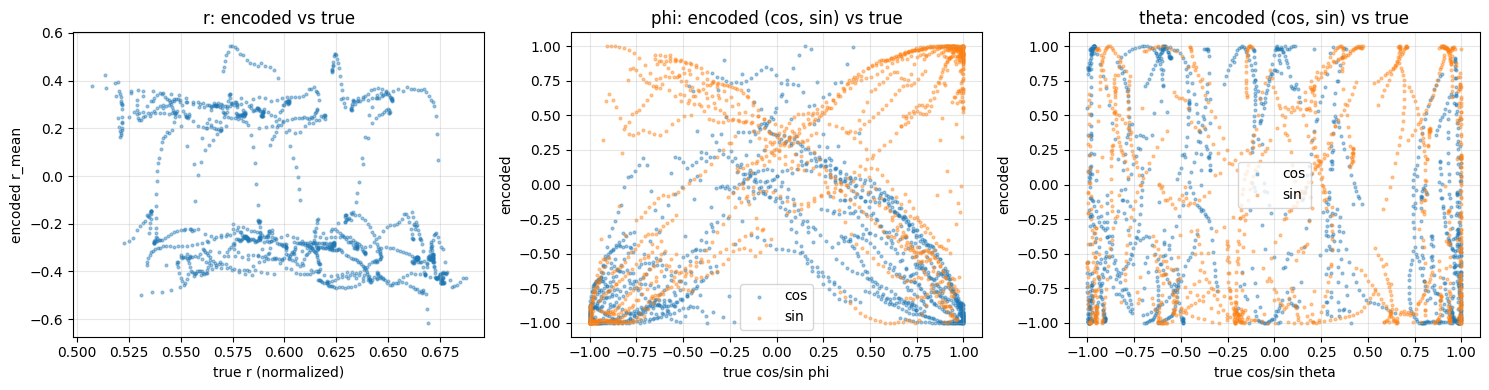

In [55]:
N_TRIALS = 64
N_STEPS = x_test.shape[0]
frames = torch.from_numpy(x_test[:, :N_TRIALS]).float().reshape(-1, 1, 32, 32)  # (T*N, 1, 32, 32)
gt = obs_test[:, :N_TRIALS].reshape(-1, 6)                                        # (T*N, 6)

enc_out = model.encoder(frames)
r_pred = enc_out['r_mean'].cpu().numpy().squeeze()
phi_vec = enc_out['phi_vec'].cpu().numpy()
theta_vec = enc_out['theta_vec'].cpu().numpy()

r_true = gt[:, 0] / 5.0   # normalized
phi_true = gt[:, 1]
theta_true = gt[:, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(r_true, r_pred, s=4, alpha=0.4)
axes[0].set_xlabel('true r (normalized)'); axes[0].set_ylabel('encoded r_mean')
axes[0].set_title('r: encoded vs true')
axes[0].grid(alpha=0.3)

axes[1].scatter(np.cos(phi_true), phi_vec[:, 0], s=4, alpha=0.4, label='cos')
axes[1].scatter(np.sin(phi_true), phi_vec[:, 1], s=4, alpha=0.4, label='sin')
axes[1].set_xlabel('true cos/sin phi'); axes[1].set_ylabel('encoded')
axes[1].set_title('phi: encoded (cos, sin) vs true')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].scatter(np.cos(theta_true), theta_vec[:, 0], s=4, alpha=0.4, label='cos')
axes[2].scatter(np.sin(theta_true), theta_vec[:, 1], s=4, alpha=0.4, label='sin')
axes[2].set_xlabel('true cos/sin theta'); axes[2].set_ylabel('encoded')
axes[2].set_title('theta: encoded (cos, sin) vs true')
axes[2].legend(); axes[2].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 4. Reconstruction — feed encoded latents back through the decoder

Encode → decode each frame without integrating the Lagrangian. Any mismatch here is purely a VAE (encoder+decoder) issue.

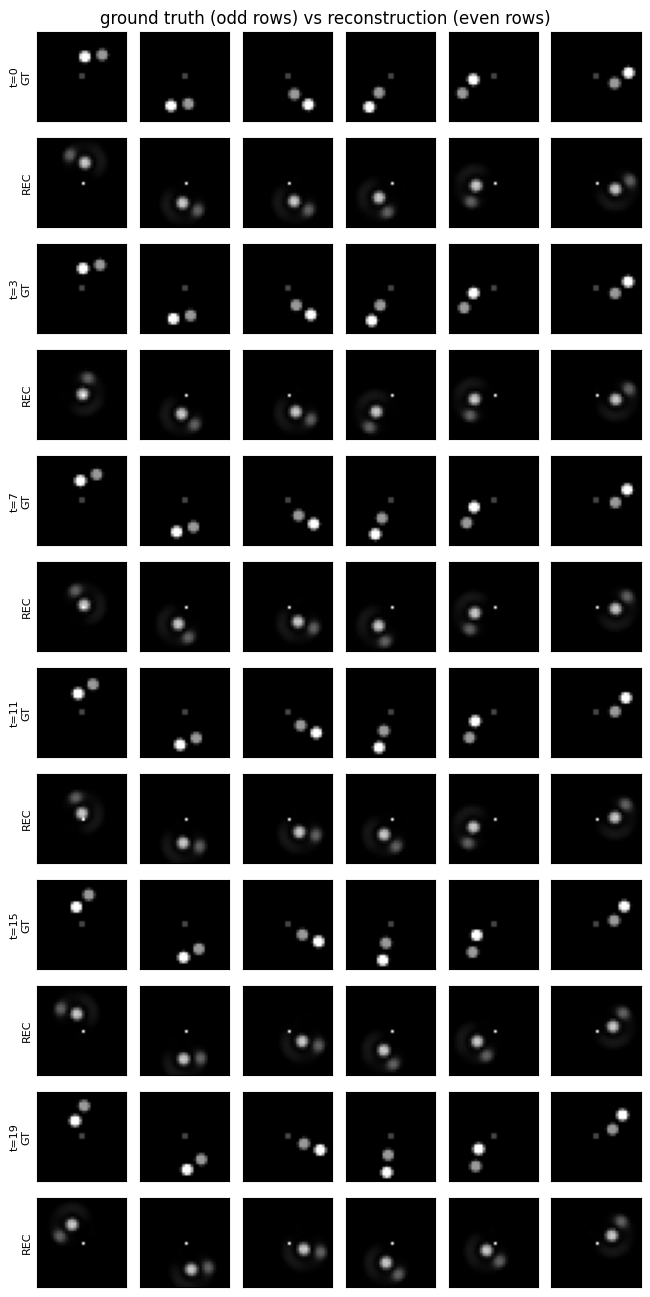

In [56]:
N_VIS = 6
sample_idx = np.linspace(0, x_test.shape[1] - 1, N_VIS).astype(int)
step_idx = np.linspace(0, x_test.shape[0] - 1, 6).astype(int)

img_in = torch.from_numpy(x_test[step_idx[:, None], sample_idx[None, :]]).float().reshape(-1, 1, 32, 32)
enc_out = model.encoder(img_in)
r = enc_out['r_mean']
cp, sp = enc_out['phi_vec'][:, 0:1], enc_out['phi_vec'][:, 1:2]
ct, st = enc_out['theta_vec'][:, 0:1], enc_out['theta_vec'][:, 1:2]
img_rec = model.decoder(r, cp, sp, ct, st).cpu().numpy().reshape(len(step_idx), N_VIS, 32, 32)
img_gt = x_test[step_idx[:, None], sample_idx[None, :]]

fig, axes = plt.subplots(2 * len(step_idx), N_VIS, figsize=(N_VIS * 1.1, 2 * len(step_idx) * 1.1))
for si, s in enumerate(step_idx):
    for ti, n in enumerate(sample_idx):
        ax_gt = axes[2 * si, ti]
        ax_rec = axes[2 * si + 1, ti]
        ax_gt.imshow(img_gt[si, ti], cmap='gray', vmin=0, vmax=1)
        ax_rec.imshow(np.clip(img_rec[si, ti], 0, 1), cmap='gray', vmin=0, vmax=1)
        ax_gt.set_xticks([]); ax_gt.set_yticks([])
        ax_rec.set_xticks([]); ax_rec.set_yticks([])
        if ti == 0:
            ax_gt.set_ylabel(f't={s}\nGT', fontsize=8)
            ax_rec.set_ylabel('REC', fontsize=8)
fig.suptitle('ground truth (odd rows) vs reconstruction (even rows)')
fig.tight_layout(); plt.show()

## 5. Lagrangian rollout — multi-step prediction

Encode frame 0 + frame 1 → integrate the Lag_Net for T steps → decode. Compare to the full ground-truth sequence.

This tests the **dynamics** in addition to the VAE. A common failure mode: VAE is fine but the Lagrangian drifts after a few steps.

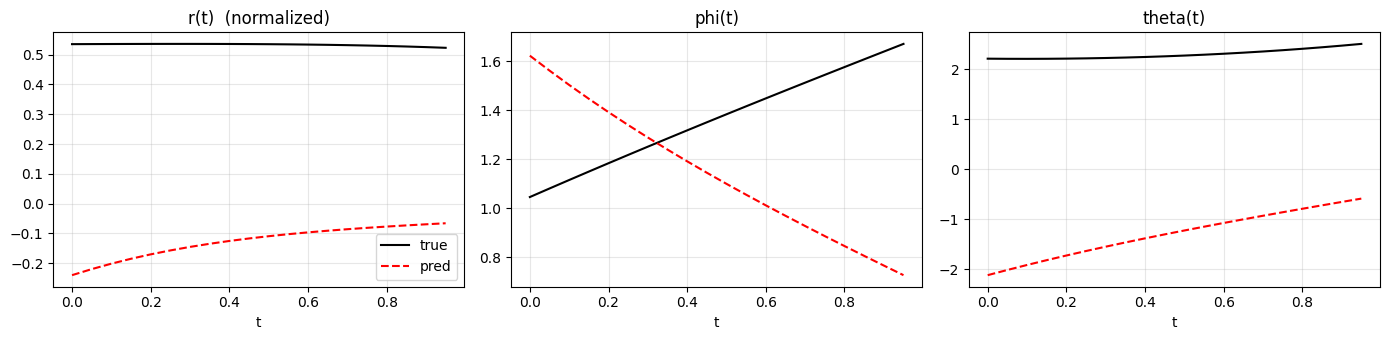

In [57]:
TRIAL = 0
T_roll = x_test.shape[0]
dt = t[1] - t[0]

x0_img = torch.from_numpy(x_test[0, TRIAL:TRIAL+1]).float().unsqueeze(1)
x1_img = torch.from_numpy(x_test[1, TRIAL:TRIAL+1]).float().unsqueeze(1)
o0 = model.encoder(x0_img)
o1 = model.encoder(x1_img)

r0 = o0['r_mean']
phi0 = o0['phi_vec']
theta0 = o0['theta_vec']
r1 = o1['r_mean']
phi1 = o1['phi_vec']
theta1 = o1['theta_vec']

r_dot0 = (r1 - r0) / dt
def angle_vel(v0, v1, dt):
    dcos = v1[:, 0:1] - v0[:, 0:1]
    dsin = v1[:, 1:2] - v0[:, 1:2]
    return (-dcos * v0[:, 1:2] + dsin * v0[:, 0:1]) / dt
phi_dot0 = angle_vel(phi0, phi1, dt)
theta_dot0 = angle_vel(theta0, theta1, dt)

u0 = torch.zeros(1, 1)
z0 = torch.cat([r0, phi0, theta0, r_dot0, phi_dot0, theta_dot0, u0], dim=1)
with torch.enable_grad():
    z0_g = z0.detach().requires_grad_(True)
    t_eval = torch.from_numpy(t).float()
    zT = odeint(model.ode, z0_g, t_eval, method='euler')
zT = zT.detach()

r_pred = zT[:, 0, 0].numpy()
phi_pred = np.arctan2(zT[:, 0, 2].numpy(), zT[:, 0, 1].numpy())
theta_pred = np.arctan2(zT[:, 0, 4].numpy(), zT[:, 0, 3].numpy())

r_true = obs_test[:, TRIAL, 0] / 5.0
phi_true = obs_test[:, TRIAL, 1]
theta_true = obs_test[:, TRIAL, 2]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(t, r_true, 'k-', label='true'); axes[0].plot(t, r_pred, 'r--', label='pred')
axes[0].set_title('r(t)  (normalized)'); axes[0].set_xlabel('t'); axes[0].legend()
axes[1].plot(t, phi_true, 'k-', label='true'); axes[1].plot(t, phi_pred, 'r--', label='pred')
axes[1].set_title('phi(t)'); axes[1].set_xlabel('t')
axes[2].plot(t, theta_true, 'k-', label='true'); axes[2].plot(t, theta_pred, 'r--', label='pred')
axes[2].set_title('theta(t)'); axes[2].set_xlabel('t')
for ax in axes: ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 6. Learned potential landscape V(r, θ)

Plot `V_net(r, cos θ, sin θ)` over a grid. For true gravity:
- leading term is Kepler `-2μm/r` → V should **drop as `r` increases in magnitude** (it's negative and gets more negative as `r` decreases toward the body)
- gravity-gradient correction `-(μmℓ²/r³)(3cos²θ - 1)` is `θ`-dependent; small compared to Kepler for `r ≫ ℓ`

The **overall shape** (predominantly `r`-dependent, θ-modulation weak) is the signature we want to see.

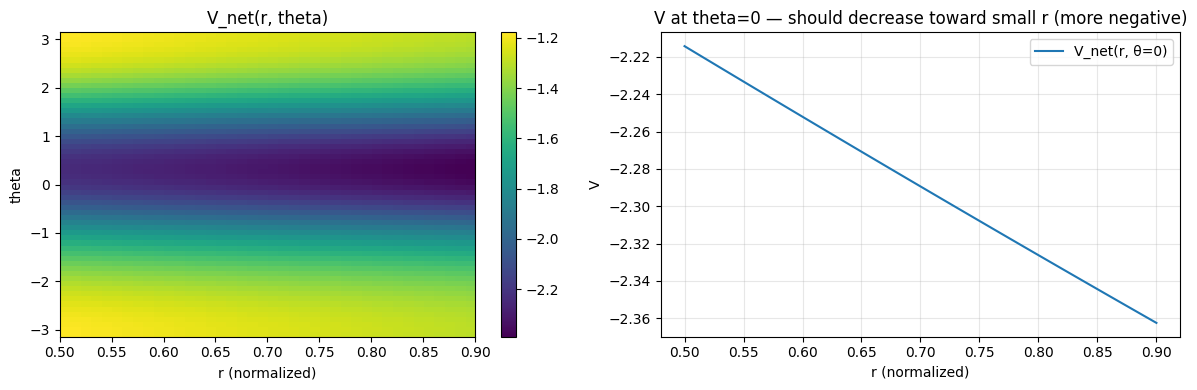

In [58]:
r_grid = np.linspace(0.5, 0.9, 40)        # normalized (true r ≈ 2.5–4.5)
theta_grid = np.linspace(-np.pi, np.pi, 60)
R, TH = np.meshgrid(r_grid, theta_grid)
grid = np.stack([R, np.cos(TH), np.sin(TH)], axis=-1).reshape(-1, 3)
V = model.ode.V_net(torch.from_numpy(grid).float()).detach().cpu().numpy().reshape(R.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(V, extent=[r_grid.min(), r_grid.max(), theta_grid.min(), theta_grid.max()],
               aspect='auto', origin='lower', cmap='viridis')
axes[0].set_xlabel('r (normalized)'); axes[0].set_ylabel('theta')
axes[0].set_title('V_net(r, theta)')
plt.colorbar(im, ax=axes[0])

# Slice at theta=0 — should look Kepler-like
axes[1].plot(r_grid, V[len(theta_grid)//2], label='V_net(r, θ=0)')
axes[1].set_xlabel('r (normalized)'); axes[1].set_ylabel('V')
axes[1].set_title('V at theta=0 — should decrease toward small r (more negative)')
axes[1].grid(alpha=0.3); axes[1].legend()
fig.tight_layout(); plt.show()


## 7. Learned mass matrix M(r)

True `M` for the rigid dumbbell:
```
M(r) = [[2m,          0,          0],
        [0,    2m(r² + ℓ²),    2mℓ²],
        [0,         2mℓ²,      2mℓ²]]
```

Signatures:
- `M[0,0]` constant (= 2m = 2)
- `M[1,1]` grows quadratically with `r`
- `M[2,2]` constant (= 2mℓ² = 2)
- `M[1,2] = M[2,1]` = 2mℓ² = 2 (constant off-diagonal)

Note: the learned `M` is in normalized-pixel units, so absolute values will differ from the world-frame physics — but the **functional shape vs r** should match.

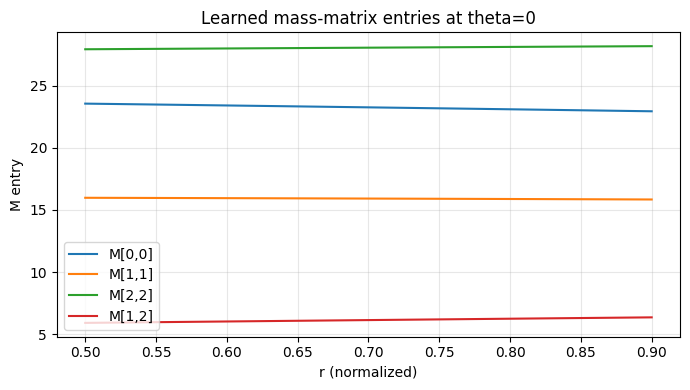

In [59]:
r_grid = np.linspace(0.5, 0.9, 40)
theta_fixed = 0.0
grid = np.stack([r_grid, np.cos(theta_fixed) * np.ones_like(r_grid),
                 np.sin(theta_fixed) * np.ones_like(r_grid)], axis=-1)
M = model.ode.M_net(torch.from_numpy(grid).float()).detach().cpu().numpy()  # (40, 3, 3)

fig, ax = plt.subplots(figsize=(7, 4))
labels = [('M[0,0]', 0, 0), ('M[1,1]', 1, 1), ('M[2,2]', 2, 2), ('M[1,2]', 1, 2)]
for lab, i, j in labels:
    ax.plot(r_grid, M[:, i, j], label=lab)
ax.set_xlabel('r (normalized)'); ax.set_ylabel('M entry')
ax.set_title('Learned mass-matrix entries at theta=0')
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()


## 9. Canonical decoder sprites

The decoder builds every reconstruction by rotating + translating two canonical sprites:
- `body_canon` — should look like a **dumbbell along +x** (head + tail offset from origin).
- `planet_canon` — should look like a **single bright pixel at the image center**.

**Failure mode:** if `body_canon` is rotation-symmetric (a blob or ring), the decoder can't represent attitude — every REC frame looks identical regardless of encoded θ/φ. This traps training in a bad equilibrium because the encoder gets no gradient to sharpen its angular latents.

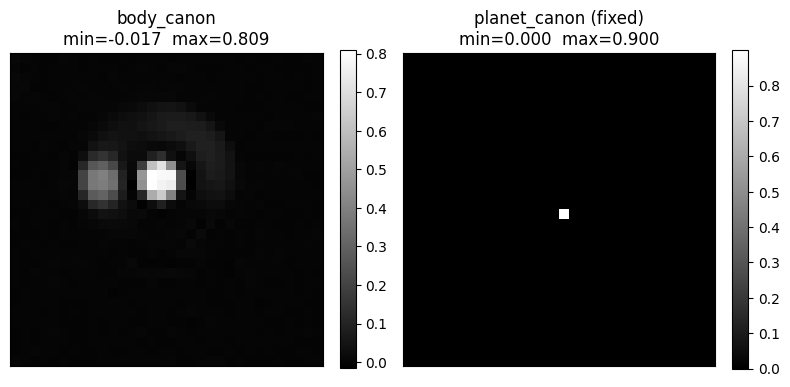

body_canon vs rotate(90deg) relative L1 = 1.6785  (close to 0 = rotation-symmetric = bad)


In [60]:
d = 32
ones = torch.ones(1, 1)
body_canon = model.decoder.obs_net_body(ones).view(d, d).cpu().numpy()
planet_canon = model.decoder.planet_template.view(d, d).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
im0 = axes[0].imshow(body_canon, cmap='gray')
axes[0].set_title(f'body_canon\nmin={body_canon.min():.3f}  max={body_canon.max():.3f}')
axes[0].set_xticks([]); axes[0].set_yticks([])
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(planet_canon, cmap='gray')
axes[1].set_title(f'planet_canon (fixed)\nmin={planet_canon.min():.3f}  max={planet_canon.max():.3f}')
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(im1, ax=axes[1], fraction=0.046)

fig.tight_layout(); plt.show()

import scipy.ndimage as ndi
rot = ndi.rotate(body_canon, 90, reshape=False)
asym = np.abs(body_canon - rot).mean() / (np.abs(body_canon).mean() + 1e-8)
print(f'body_canon vs rotate(90deg) relative L1 = {asym:.4f}  (close to 0 = rotation-symmetric = bad)')

## 10. How to read these plots

| Symptom | Diagnosis |
|---|---|
| §3: all three scatters are blobs, not curves | Total encoder collapse — training hasn't started. Increase `--max_epochs`. |
| §3: `r` scatter is a curve but `theta` is a blob | Attitude info isn't being picked up. Check image rendering — is head/tail distinguishable? |
| §4: GT and REC look similar | VAE is healthy |
| §4: all REC frames look identical | Encoder collapse (confirmed by §3) |
| §5: curves agree for first few steps then diverge | Lagrangian is learning but dynamics aren't tight yet — train longer |
| §5: prediction flat or explodes | `Lag_Net` isn't integrating sensibly. Check velocity estimates aren't NaN. |
| §6: V depends only on θ, not r | Sign flip or gross numerical issue. Expected is mostly-r-dependence |
| §7: `M[0,0]` not constant | Expected after training; with too few epochs it won't be clean |
| §9: `body_canon` looks like a blob/ring (low asymmetry score) | Decoder sprite collapsed — it has no angular structure, so rotations do nothing. Root cause of encoder collapse. |